# Previsão do valor de imóveis com SVR

**Aluno(a):** _preencher_  
**Disciplina:** Inteligência Artificial

Atividade de regressão com **Support Vector Regression** (scikit-learn) sobre o conjunto *Housing* do Kaggle. A ideia é estimar `median_house_value` a partir das demais colunas e chegar a um **R² acima de 0,65 nos dados de teste** (divisão 80/20, `random_state=42`).

O notebook segue a ordem das etapas do enunciado; a tabela com todos os experimentos e a conclusão ficam no final.

In [1]:
# Importações
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")

## 1. Primeiro contato com os dados

In [2]:
# Leitura do CSV (deixar o housing.csv na mesma pasta deste notebook)
housing = pd.read_csv("/kaggle/input/datasets/kathuman/housing/housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.2300,37.8800,41.0000,880.0000,129.0000,322.0000,126.0000,8.3252,"452,600.0000",NEAR BAY
1,-122.2200,37.8600,21.0000,"7,099.0000","1,106.0000","2,401.0000","1,138.0000",8.3014,"358,500.0000",NEAR BAY
2,-122.2400,37.8500,52.0000,"1,467.0000",190.0000,496.0000,177.0000,7.2574,"352,100.0000",NEAR BAY
3,-122.2500,37.8500,52.0000,"1,274.0000",235.0000,558.0000,219.0000,5.6431,"341,300.0000",NEAR BAY
4,-122.2500,37.8500,52.0000,"1,627.0000",280.0000,565.0000,259.0000,3.8462,"342,200.0000",NEAR BAY


### 1.1 Tamanho do conjunto

In [3]:
print("Dimensões (linhas, colunas):", housing.shape)
print("Quantidade de linhas  :", housing.shape[0])
print("Quantidade de colunas :", housing.shape[1])

Dimensões (linhas, colunas): (20640, 10)
Quantidade de linhas  : 20640
Quantidade de colunas : 10


### 1.2 Tipos das colunas

In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
# Lista das colunas numéricas e das não numéricas
num_cols = housing.select_dtypes(include="number").columns.tolist()
cat_cols = housing.select_dtypes(exclude="number").columns.tolist()
print("Colunas float      :", housing.select_dtypes(include="float").columns.tolist())
print("Colunas int        :", housing.select_dtypes(include="int").columns.tolist())
print("Colunas categóricas:", cat_cols)
print()
print(housing["ocean_proximity"].value_counts())

Colunas float      : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Colunas int        : []
Colunas categóricas: ['ocean_proximity']

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


**O que o `info()` mostra**

| Tipo | Colunas |
|---|---|
| float64 | as 9 colunas numéricas, de `longitude` até `median_house_value` |
| int | nenhuma — até as contagens (`population`, `households`...) vieram como float |
| texto / categórica | `ocean_proximity` (5 valores possíveis; `ISLAND` aparece só 5 vezes) |

Um detalhe importante para interpretar tudo o que vem depois: **uma linha não é um imóvel, é um distrito** do censo da Califórnia. Por isso existem colunas como "total de cômodos" e "população". O alvo, `median_house_value`, é a mediana do valor dos imóveis daquele distrito, em dólares.

### 1.3 Estatísticas descritivas

In [6]:
housing.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,"20,640.0000",-119.5697,2.0035,-124.3500,-121.8000,-118.4900,-118.0100,-114.3100
latitude,"20,640.0000",35.6319,2.1360,32.5400,33.9300,34.2600,37.7100,41.9500
housing_median_age,"20,640.0000",28.6395,12.5856,1.0000,18.0000,29.0000,37.0000,52.0000
total_rooms,"20,640.0000","2,635.7631","2,181.6153",2.0000,"1,447.7500","2,127.0000","3,148.0000","39,320.0000"
total_bedrooms,"20,433.0000",537.8706,421.3851,1.0000,296.0000,435.0000,647.0000,"6,445.0000"
population,"20,640.0000","1,425.4767","1,132.4621",3.0000,787.0000,"1,166.0000","1,725.0000","35,682.0000"
households,"20,640.0000",499.5397,382.3298,1.0000,280.0000,409.0000,605.0000,"6,082.0000"
median_income,"20,640.0000",3.8707,1.8998,0.4999,2.5634,3.5348,4.7432,15.0001
median_house_value,"20,640.0000","206,855.8169","115,395.6159","14,999.0000","119,600.0000","179,700.0000","264,725.0000","500,001.0000"


**Comentários sobre o `describe()`**

1. **Dispersão.** As colunas de contagem são as mais espalhadas. Em `total_rooms`, `total_bedrooms`, `population` e `households` o desvio-padrão é quase do tamanho da média e o máximo está muito longe do 3º quartil (população: 75% dos distritos têm até 1.725 pessoas, mas o maior tem 35.682).
2. **Valores altos.** Além dessas contagens, o próprio alvo trabalha com números na casa das centenas de milhares, enquanto `median_income` fica entre 0,5 e 15. Essa diferença de ordem de grandeza vai pesar bastante no SVR.
3. **Mínimos e máximos suspeitos.** O preço para exatamente em 500.001 e a idade em 52: são tetos impostos na coleta, não valores observados. A renda também tem piso (0,4999) e teto (15,0001). No outro extremo há distritos com apenas 2 cômodos ou 1 domicílio.
4. **Relação com o preço.** Pelo senso comum, renda e localização devem ser as que mais explicam o valor; a matriz de correlação da seção 2 confirma a renda.

### 1.4 Dados faltantes e linhas repetidas

In [7]:
print("Valores nulos por coluna:")
print(housing.isnull().sum())
print()
print(f"Percentual de nulos em total_bedrooms: {housing['total_bedrooms'].isnull().mean()*100:.2f}%")
print("Linhas duplicadas:", housing.duplicated().sum())

Valores nulos por coluna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Percentual de nulos em total_bedrooms: 1.00%
Linhas duplicadas: 0


Só uma coluna tem buracos: `total_bedrooms`, com **207 valores nulos (cerca de 1%)**. Linhas duplicadas não existem.

**Como os nulos serão tratados:** substituição pela **mediana** da coluna.

- Por que não a média? Porque a coluna tem cauda longa e alguns distritos enormes, que puxariam a média para cima.
- Por que não apagar as linhas? Porque seriam 207 distritos perdidos por causa de uma única coluna, sendo que o restante da linha está completo.

A substituição acontece dentro da função de preparação (seção 5).

## 2. Análise exploratória

### 2.1 Histograma do alvo

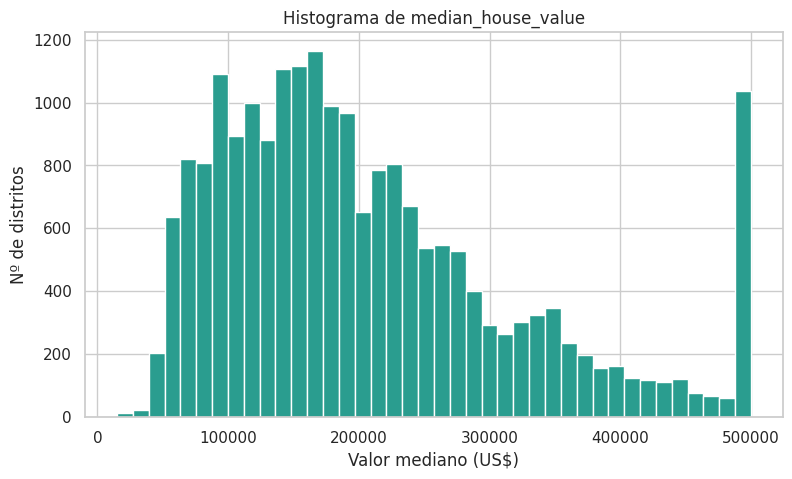

Distritos no teto de 500.001: 965 (4.68%)


In [8]:
TARGET = "median_house_value"

plt.figure(figsize=(9, 5))
plt.hist(housing[TARGET], bins=40, color="#2a9d8f", edgecolor="white")
plt.xlabel("Valor mediano (US$)")
plt.ylabel("Nº de distritos")
plt.title("Histograma de median_house_value")
plt.show()

print("Distritos no teto de 500.001:", (housing[TARGET] >= 500001).sum(),
      f"({(housing[TARGET] >= 500001).mean()*100:.2f}%)")

A maior parte dos distritos fica entre 100 e 250 mil dólares e a cauda se estende para a direita. A última barra, bem mais alta que as vizinhas, não é um pico real de mercado: são os distritos cujo valor foi **truncado em 500.001**. Para eles só sabemos que o preço é "500 mil ou mais".

### 2.2 Boxplots

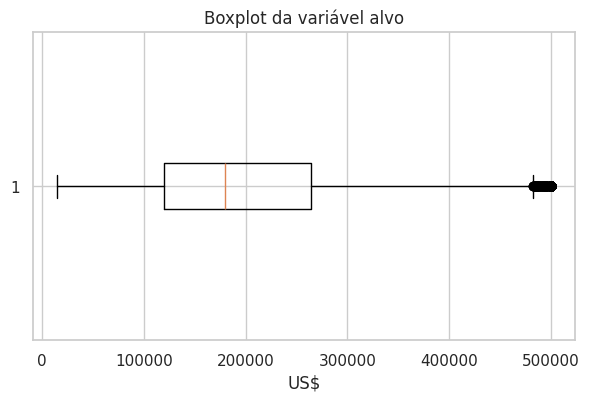

In [9]:
plt.figure(figsize=(7, 4))
plt.boxplot(housing[TARGET].dropna(), vert=False)
plt.title("Boxplot da variável alvo")
plt.xlabel("US$")
plt.show()

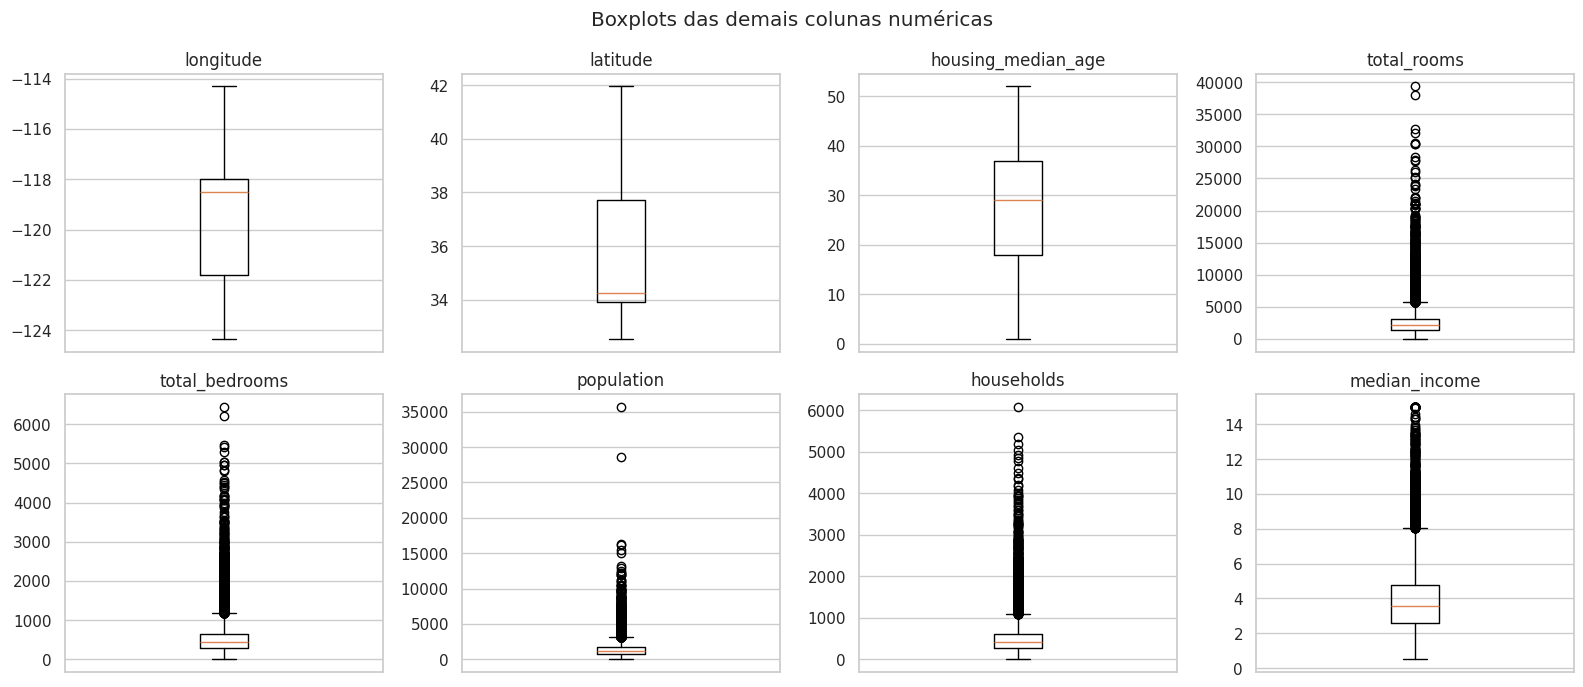

In [10]:
# Um boxplot para cada coluna numérica (menos o alvo)
demais = [c for c in num_cols if c != TARGET]
fig, eixos = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(eixos.ravel(), demais):
    ax.boxplot(housing[col].dropna())
    ax.set_title(col)
    ax.set_xticks([])
plt.suptitle("Boxplots das demais colunas numéricas")
plt.tight_layout()
plt.show()

Pelos boxplots, as quatro colunas de contagem têm uma fila longa de pontos acima do bigode superior. Renda e preço também têm pontos extremos, mas só para cima. Latitude, longitude e idade ficam inteiramente dentro dos bigodes.

### 2.3 Matriz de correlação

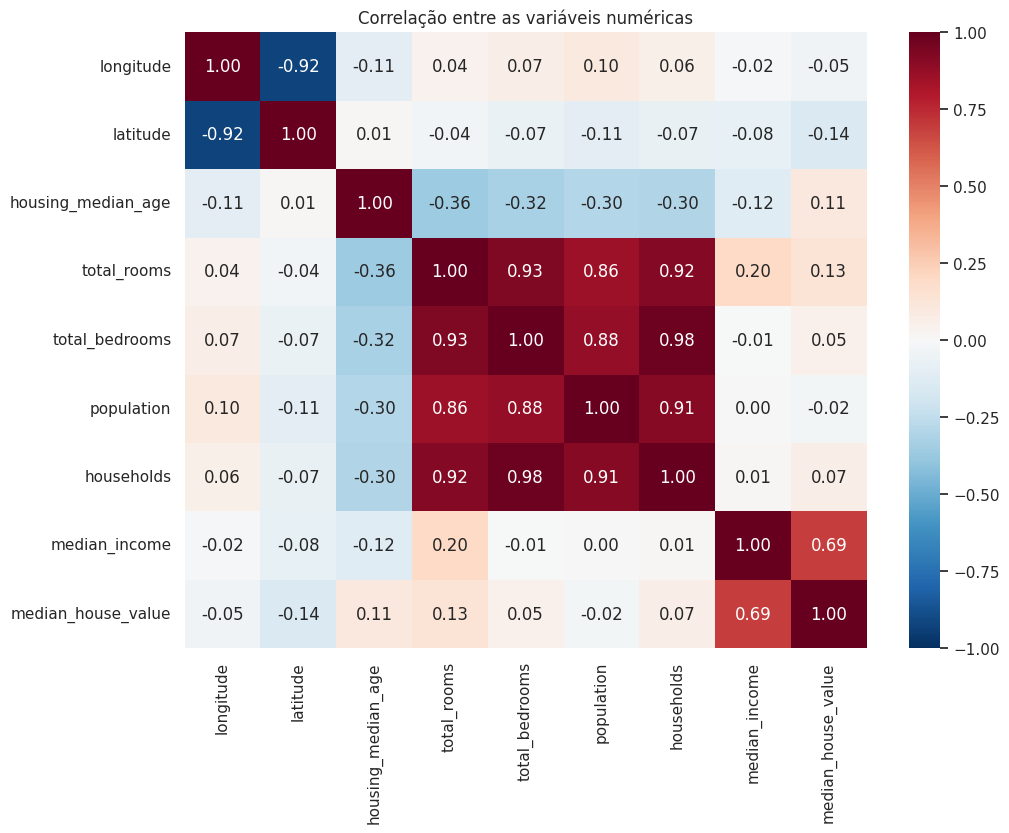

Correlação de cada variável com o preço:
median_house_value    1.0000
median_income         0.6881
total_rooms           0.1342
housing_median_age    0.1056
households            0.0658
total_bedrooms        0.0497
population           -0.0246
longitude            -0.0460
latitude             -0.1442
Name: median_house_value, dtype: float64


In [11]:
plt.figure(figsize=(11, 8))
sns.heatmap(housing.corr(numeric_only=True), cmap="RdBu_r", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlação entre as variáveis numéricas")
plt.show()

print("Correlação de cada variável com o preço:")
print(housing.corr(numeric_only=True)[TARGET].sort_values(ascending=False))

**O que a matriz mostra**

- **Mais ligada ao preço:** `median_income`, com r ≈ 0,69. Nenhuma outra passa de 0,15 em módulo.
- **Pouco ligadas (linearmente):** `population`, `longitude`, `total_bedrooms` e `households` ficam praticamente em zero; `latitude`, `total_rooms` e `housing_median_age` ficam entre 0,10 e 0,15. Vale lembrar que o coeficiente de Pearson só enxerga relação em linha reta — a posição geográfica influencia o preço, mas não dessa forma.
- **Redundantes:** as quatro contagens andam juntas (correlações de 0,86 a 0,98), pois todas refletem o porte do distrito. Latitude e longitude também são muito correlacionadas entre si (≈ −0,92), consequência do formato inclinado do estado.

Isso sugere transformar as contagens em **proporções** (por domicílio, por cômodo), o que é feito mais adiante como parte do desafio extra.

## 3. Identificação dos outliers

A regra usada é a do **intervalo interquartil (IQR)**: calcula-se `IQR = Q3 − Q1` e marca-se como outlier tudo o que estiver fora de `[Q1 − 1,5·IQR ; Q3 + 1,5·IQR]`. Aqui a intenção é só **contar e observar** — nenhuma alteração é feita nos dados nesta seção.

In [12]:
def calcular_limites(s):
    # Limites do IQR: Q1 - 1,5*IQR e Q3 + 1,5*IQR
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

def resumo_outliers(dados, colunas):
    # Para cada coluna: mínimo, máximo, limites, nº e % de outliers
    linhas = []
    for col in colunas:
        s = dados[col].dropna()
        li, ls = calcular_limites(s)
        qtd = ((s < li) | (s > ls)).sum()
        linhas.append({
            "variável": col,
            "mínimo": s.min(),
            "máximo": s.max(),
            "limite inferior": li,
            "limite superior": ls,
            "outliers": qtd,
            "% outliers": 100 * qtd / len(s),
            "método": "IQR (1,5)",
        })
    return pd.DataFrame(linhas).set_index("variável")

quadro_outliers = resumo_outliers(housing, num_cols)
quadro_outliers

,mínimo,máximo,limite inferior,limite superior,outliers,% outliers,método
variável,,,,,,,
longitude,-124.3500,-114.3100,-127.4850,-112.3250,0,0.0000,"IQR (1,5)"
latitude,32.5400,41.9500,28.2600,43.3800,0,0.0000,"IQR (1,5)"
housing_median_age,1.0000,52.0000,-10.5000,65.5000,0,0.0000,"IQR (1,5)"
total_rooms,2.0000,"39,320.0000","-1,102.6250","5,698.3750",1287,6.2355,"IQR (1,5)"
total_bedrooms,1.0000,"6,445.0000",-230.5000,"1,173.5000",1271,6.2203,"IQR (1,5)"
population,3.0000,"35,682.0000",-620.0000,"3,132.0000",1196,5.7946,"IQR (1,5)"
households,1.0000,"6,082.0000",-207.5000,"1,092.5000",1220,5.9109,"IQR (1,5)"
median_income,0.4999,15.0001,-0.7064,8.0130,681,3.2994,"IQR (1,5)"
median_house_value,"14,999.0000","500,001.0000","-98,087.5000","482,412.5000",1071,5.1890,"IQR (1,5)"


In [13]:
# Exemplos de valores extremos, para entender o que eles são
print("Distritos com maior população:")
print(housing.nlargest(5, "population")[["population", "households", "total_rooms", "median_income", TARGET]])
print()
pessoas_por_domicilio = housing["population"] / housing["households"]
print("Maiores valores de pessoas por domicílio:")
print(pessoas_por_domicilio.nlargest(5))

Distritos com maior população:
       population  households  total_rooms  median_income  median_house_value
15360 35,682.0000  4,769.0000  25,135.0000         2.5729        134,400.0000
9880  28,566.0000  6,082.0000  32,627.0000         2.3087        118,800.0000
13139 16,305.0000  5,358.0000  39,320.0000         4.9516        153,700.0000
10309 16,122.0000  5,189.0000  37,937.0000         7.4947        366,300.0000
6057  15,507.0000  5,050.0000  32,054.0000         6.0191        253,900.0000

Maiores valores de pessoas por domicílio:
19006   1,243.3333
3364      599.7143
16669     502.4615
13034     230.1724
9172       83.1714
dtype: float64


**Resumo do que foi encontrado**

| Grupo | % de outliers | Observação |
|---|---|---|
| `total_rooms`, `total_bedrooms`, `population`, `households` | 5,8% a 6,3% | todos acima do limite superior; distritos existentes, só que muito grandes |
| `median_income` | 3,3% | distritos de renda elevada |
| `median_house_value` | 5,2% | praticamente os distritos presos no teto de 500.001 |
| `longitude`, `latitude`, `housing_median_age` | 0% | nada fora dos limites |

A divisão população/domicílios revela casos impossíveis para moradias comuns: 502, 599 e até 1.243 pessoas por domicílio. Devem ser instituições (presídio, alojamento, quartel) contadas como um único domicílio.

## 4. Tratamento dos outliers

Não foi aplicada uma regra única para tudo. Cada grupo de variáveis recebeu uma decisão:

**a) Contagens (`total_rooms`, `total_bedrooms`, `population`, `households`) → limitar aos valores do IQR (Opção B).**  
Esses distritos existem, então apagá-los seria perder informação verdadeira. O problema deles é outro: um valor 15 vezes maior que o 3º quartil domina a escala da coluna e bagunça o cálculo de distâncias do kernel. Cortando no limite superior, o distrito continua na base e continua sendo "grande".

**b) Proporções criadas no desafio extra → limitar aos valores do IQR (Opção B).**  
Aqui os extremos são de fato anômalos (o caso das 1.243 pessoas por domicílio).

**c) `median_income` → manter (Opção C).**  
Renda alta não é erro e é a melhor pista sobre o preço. O teste da seção 9 mostra que cortar a renda prejudica o modelo.

**d) `median_house_value` → manter (Opção C).**  
São imóveis caros de verdade. Excluir 5% da base só para subir o R² iria contra as regras da atividade, e mexer no alvo do teste tornaria a avaliação sem sentido.

**e) `longitude`, `latitude`, `housing_median_age` → nada a fazer.**

Consequência prática: **a base continua com as 20.640 linhas**, então todos os experimentos são avaliados exatamente nos mesmos 4.128 distritos de teste.

In [14]:
COLS_CONTAGEM = ["total_rooms", "total_bedrooms", "population", "households"]
COLS_PROPORCAO = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]

def limitar_valores(dados, colunas):
    # Corta os valores que passam dos limites do IQR (nenhuma linha é apagada)
    dados = dados.copy()
    for col in colunas:
        li, ls = calcular_limites(dados[col])
        dados[col] = dados[col].clip(lower=li, upper=ls)
    return dados

# Verificação: mesmo nº de linhas e zero outliers nas colunas tratadas
df_teste_cap = limitar_valores(housing.fillna({"total_bedrooms": housing["total_bedrooms"].median()}), COLS_CONTAGEM)
print("Linhas antes:", len(housing), "| linhas depois:", len(df_teste_cap))
resumo_outliers(df_teste_cap, COLS_CONTAGEM)[["mínimo", "máximo", "outliers", "% outliers"]]

Linhas antes: 20640 | linhas depois: 20640


,mínimo,máximo,outliers,% outliers
variável,,,,
total_rooms,2.0000,"5,698.3750",0,0.0000
total_bedrooms,1.0000,"1,162.6250",0,0.0000
population,3.0000,"3,132.0000",0,0.0000
households,1.0000,"1,092.5000",0,0.0000


## 5. Preparação dos dados

Todo o tratamento foi colocado em uma única função com "chaves" de liga/desliga. Assim dá para repetir o treino ativando um tratamento por vez e ver quanto cada um contribui.

O que a função faz, na ordem:

1. preenche os nulos de `total_bedrooms` com a mediana;
2. opcionalmente cria as proporções (desafio extra);
3. opcionalmente corta os outliers das colunas escolhidas;
4. converte `ocean_proximity` em colunas 0/1 com `pd.get_dummies()`;
5. separa `X` (tudo menos o alvo) e `y` (o alvo).

In [15]:
def montar_base(dados, preencher_nulos=True, dummies=True, capping=None, criar_proporcoes=False):
    # Aplica os tratamentos escolhidos e devolve X e y
    dados = dados.copy()

    # nulos de total_bedrooms -> mediana
    if preencher_nulos:
        dados["total_bedrooms"] = dados["total_bedrooms"].fillna(dados["total_bedrooms"].median())
    else:
        # sem preencher, a coluna precisa sair (SVR não aceita NaN)
        dados = dados.drop(columns=["total_bedrooms"])

    # novas colunas: proporções (desafio extra)
    if criar_proporcoes:
        dados["rooms_per_household"] = dados["total_rooms"] / dados["households"]
        dados["bedrooms_per_room"] = dados["total_bedrooms"] / dados["total_rooms"]
        dados["population_per_household"] = dados["population"] / dados["households"]

    # corte dos outliers pelo IQR
    if capping:
        dados = limitar_valores(dados, [c for c in capping if c in dados.columns])

    # ocean_proximity -> colunas 0/1
    if dummies:
        dados = pd.get_dummies(dados, columns=["ocean_proximity"], dtype=float)
    else:
        dados = dados.drop(columns=["ocean_proximity"])

    X = dados.drop(TARGET, axis=1)
    y = dados[TARGET]
    return X, y

X, y = montar_base(housing, capping=COLS_CONTAGEM)
print("X:", X.shape, "| y:", y.shape)
X.head()

X: (20640, 13) | y: (20640,)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.2300,37.8800,41.0000,880.0000,129.0000,322.0000,126.0000,8.3252,0.0000,0.0000,0.0000,1.0000,0.0000
1,-122.2200,37.8600,21.0000,"5,698.3750","1,106.0000","2,401.0000","1,092.5000",8.3014,0.0000,0.0000,0.0000,1.0000,0.0000
2,-122.2400,37.8500,52.0000,"1,467.0000",190.0000,496.0000,177.0000,7.2574,0.0000,0.0000,0.0000,1.0000,0.0000
3,-122.2500,37.8500,52.0000,"1,274.0000",235.0000,558.0000,219.0000,5.6431,0.0000,0.0000,0.0000,1.0000,0.0000
4,-122.2500,37.8500,52.0000,"1,627.0000",280.0000,565.0000,259.0000,3.8462,0.0000,0.0000,0.0000,1.0000,0.0000


## 6 e 7. Divisão treino/teste e padronização

- **Divisão:** 80% para treino e 20% para teste, com `random_state=42`, como pedido.
- **Padronização:** o `StandardScaler` aprende média e desvio-padrão **apenas com o treino** (`fit_transform`) e o teste só recebe o `transform`. Se o scaler visse o teste, parte da informação dele vazaria para o treinamento.

As duas funções abaixo são usadas em todos os experimentos. A segunda aceita uma opção para padronizar também o **alvo** — o motivo aparece na seção 9. Quando isso acontece, o scaler do alvo é ajustado só em `y_train` e a previsão é devolvida para dólares antes de qualquer métrica.

In [16]:
def separar_e_escalar(X, y, escalar_X=True):
    # 80% treino, 20% teste
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42
    )
    # scaler aprende só com o treino
    if escalar_X:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test

def rodar_modelo(X, y, modelo, escalar_X=True, alvo="original"):
    # alvo = "original"   -> y em dólares, sem transformação
    # alvo = "padronizado" -> y padronizado com StandardScaler (fit no treino)
    # alvo = "log"        -> log(y) padronizado
    X_train, X_test, y_train, y_test = separar_e_escalar(X, y, escalar_X)

    if alvo == "original":
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
    else:
        y_tr = np.log(y_train) if alvo == "log" else y_train
        scaler_y = StandardScaler()
        y_tr = scaler_y.fit_transform(y_tr.values.reshape(-1, 1)).ravel()
        modelo.fit(X_train, y_tr)
        y_pred = scaler_y.inverse_transform(modelo.predict(X_test).reshape(-1, 1)).ravel()
        if alvo == "log":
            y_pred = np.exp(y_pred)

    return {
        "R²": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "y_test": y_test,
        "y_pred": y_pred,
        "modelo": modelo,
    }

X_train, X_test, y_train, y_test = separar_e_escalar(X, y)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Média das colunas de treino após padronização ≈", X_train.mean(axis=0).round(3).max())
print("Desvio-padrão das colunas de treino ≈", X_train.std(axis=0).round(3).max())

Treino: (16512, 13) | Teste: (4128, 13)
Média das colunas de treino após padronização ≈ -0.0
Desvio-padrão das colunas de treino ≈ 1.0


## 8. Modelo inicial (baseline)

Ponto de partida: `SVR()` sem alterar nenhum parâmetro (RBF, `C=1`, `epsilon=0.1`) e sem tratar os dados. Como o SVR não aceita nulos nem texto, entram apenas as colunas numéricas completas — ficam de fora `total_bedrooms` e `ocean_proximity`. Nada é padronizado.

In [17]:
historico = []   # lista com o resultado de cada experimento

def anotar(nome, tratamento, res, kernel="rbf", C=1, epsilon=0.1, gamma="scale"):
    historico.append({
        "Modelo": nome, "Tratamento": tratamento, "Kernel": kernel,
        "C": C, "Epsilon": epsilon, "Gamma": gamma,
        "R²": res["R²"], "MAE": res["MAE"], "RMSE": res["RMSE"],
    })
    print(f"{nome}: R² = {res['R²']:.4f} | MAE = {res['MAE']:,.0f} | RMSE = {res['RMSE']:,.0f}")

X_base, y_base = montar_base(housing, preencher_nulos=False, dummies=False)
res1 = rodar_modelo(X_base, y_base, SVR(), escalar_X=False)
anotar("M1 - Baseline", "Sem tratamento", res1)

M1 - Baseline: R² = -0.0486 | MAE = 87,341 | RMSE = 117,222


Resultado: **R² abaixo de zero**. Um R² negativo quer dizer que chutar a média dos preços para todo mundo daria um erro menor do que o do modelo. Na prática, o SVR não aprendeu nada.

## 9. Antes e depois de cada tratamento (Etapa 12 do enunciado)

Os modelos abaixo são cumulativos: cada um repete o anterior e adiciona **uma** mudança, sempre com `SVR()` padrão e o mesmo teste. Esta comparação vem antes da otimização porque é ela que define com quais dados a otimização vai trabalhar.

In [18]:
# M2: nulos preenchidos e ocean_proximity convertida
X2, y2 = montar_base(housing)
res2 = rodar_modelo(X2, y2, SVR(), escalar_X=False)
anotar("M2 - Nulos tratados", "Nulos pela mediana + one-hot", res2)

# M3: M2 com os outliers das contagens cortados
X3, y3 = montar_base(housing, capping=COLS_CONTAGEM)
res3 = rodar_modelo(X3, y3, SVR(), escalar_X=False)
anotar("M3 - Outliers tratados", "M2 + corte de outliers (IQR)", res3)

# M4: M3 com X padronizado
res4 = rodar_modelo(X3, y3, SVR(), escalar_X=True)
anotar("M4 - X padronizado", "M3 + StandardScaler em X", res4)

M2 - Nulos tratados: R² = -0.0487 | MAE = 87,344 | RMSE = 117,229
M3 - Outliers tratados: R² = -0.0482 | MAE = 87,325 | RMSE = 117,197
M4 - X padronizado: R² = -0.0424 | MAE = 86,965 | RMSE = 116,874


Tratar nulos, cortar outliers e padronizar `X` não tirou o R² do zero. O que está travando o modelo é a **ordem de grandeza do alvo**.

No SVR, `C` é o peso dado aos erros e `epsilon` é a faixa de erro tolerada, ambos medidos na unidade de `y`. Com `y` em dólares, um `epsilon` de 0,1 e um `C` de 1 são desprezíveis diante de erros de dezenas de milhares: o modelo prefere ficar "plano" a se ajustar aos dados.

Dá para resolver de dois jeitos: usar `C` gigantesco ou **colocar o alvo na mesma escala das entradas**. A segunda opção (que é uma transformação do alvo, citada no desafio extra) foi a escolhida, porque mantém `C` e `epsilon` em valores usuais. O ajuste usa só `y_train`, e R², MAE e RMSE continuam sendo calculados em dólares.

In [19]:
# M5: M4 com o alvo também padronizado
res5 = rodar_modelo(X3, y3, SVR(), alvo="padronizado")
anotar("M5 - X e y padronizados", "M4 + StandardScaler em y", res5)

# M6: M5 com as proporções (e seus outliers cortados)
X6, y6 = montar_base(housing, capping=COLS_CONTAGEM + COLS_PROPORCAO, criar_proporcoes=True)
res6 = rodar_modelo(X6, y6, SVR(), alvo="padronizado")
anotar("M6 - Novas variáveis", "M5 + proporções", res6)

M5 - X e y padronizados: R² = 0.7507 | MAE = 37,893 | RMSE = 57,158
M6 - Novas variáveis: R² = 0.7690 | MAE = 36,740 | RMSE = 55,023


### E os outliers, fizeram diferença?

Entre os modelos 2 e 3 não dá para saber, já que o SVR ainda não funcionava. A comparação justa é esta: mesmos dados padronizados, mesmo `SVR()`, mudando **só** o tratamento dos outliers.

In [20]:
def r2_teste(**opcoes):
    Xa, ya = montar_base(housing, **opcoes)
    return rodar_modelo(Xa, ya, SVR(), alvo="padronizado")["R²"]

teste_outliers = pd.DataFrame([
    {"Variáveis": "originais", "Outliers": "mantidos", "R²": r2_teste()},
    {"Variáveis": "originais", "Outliers": "corte nas contagens", "R²": res5["R²"]},
    {"Variáveis": "originais", "Outliers": "corte nas contagens + median_income", "R²": r2_teste(capping=COLS_CONTAGEM + ["median_income"])},
    {"Variáveis": "originais + proporções", "Outliers": "mantidos", "R²": r2_teste(criar_proporcoes=True)},
    {"Variáveis": "originais + proporções", "Outliers": "corte nas contagens e proporções", "R²": res6["R²"]},
])
teste_outliers

,Variáveis,Outliers,R²
0,originais,mantidos,0.7458
1,originais,corte nas contagens,0.7507
2,originais,corte nas contagens + median_income,0.7471
3,originais + proporções,mantidos,0.7458
4,originais + proporções,corte nas contagens e proporções,0.7690


Lendo a tabela:

- cortar as contagens dá um ganho pequeno, mas positivo;
- cortar também a renda faz o R² **cair**, o que confirma a decisão de mantê-la;
- as proporções novas não ajudam em nada enquanto seus outliers estão lá — o ganho só aparece depois do corte, porque antes disso meia dúzia de valores absurdos define a escala da coluna.

## 10. Comparação de kernels (Etapa 9 do enunciado)

A partir daqui a base é sempre a mais completa: nulos preenchidos, outliers cortados, proporções incluídas, `X` e `y` padronizados. Os kernels são comparados com os mesmos `C=1` e `epsilon=0.1`.

In [21]:
kernels = []
for kernel in ["linear", "rbf", "poly", "sigmoid"]:
    res = rodar_modelo(X6, y6, SVR(kernel=kernel), alvo="padronizado")
    kernels.append({"Kernel": kernel, "R²": res["R²"], "MAE": res["MAE"], "RMSE": res["RMSE"]})
    print(f"kernel = {kernel:8s} R² = {res['R²']:.4f}")

kernels = pd.DataFrame(kernels).set_index("Kernel")
kernels

kernel = linear   R² = 0.6382
kernel = rbf      R² = 0.7690
kernel = poly     R² = 0.7066
kernel = sigmoid  R² = -9923.8886


,R²,MAE,RMSE
Kernel,,,
linear,0.6382,"47,963.9124","68,852.5191"
rbf,0.7690,"36,740.0179","55,022.7710"
poly,0.7066,"40,817.9685","62,006.6487"
sigmoid,"-9,923.8886","7,203,948.1130","11,404,237.4424"


Ordem do melhor para o pior: **RBF**, polinomial, linear e sigmoid. O linear perde porque o efeito da localização sobre o preço não é uma reta; o sigmoid simplesmente não funciona com estes dados (R² muito negativo).

## 11. Busca de hiperparâmetros com GridSearchCV (Etapa 10 do enunciado)

Validação cruzada com 5 dobras e `scoring="r2"`, usando **apenas o treino** — o teste fica guardado para a avaliação final.

O SVR fica lento rapidamente quando o número de amostras cresce, então a grade do enunciado foi adaptada em dois pontos:

- a busca roda sobre **5.000 linhas sorteadas do treino**; depois, o melhor conjunto é treinado de novo com o treino inteiro;
- o kernel linear vai só até `C=10`, já que ficou atrás do RBF e demora muito com `C` grande.

Outro ajuste: com `X` padronizado, `"scale"` e `"auto"` resultam quase no mesmo `gamma` (perto de 1 dividido pelo número de colunas). Para a busca realmente variar esse parâmetro, entraram também 0,1 e 0,2.

*Obs.: a célula da busca demora alguns minutos (cerca de 7 min em uma máquina com 2 núcleos).*

In [22]:
X_train, X_test, y_train, y_test = separar_e_escalar(X6, y6)

# alvo padronizado usando apenas y_train
scaler_y = StandardScaler()
y_train_pad = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# 5.000 linhas do treino para a busca
rng = np.random.RandomState(42)
idx_busca = rng.choice(len(X_train), size=5000, replace=False)

grade = [
    {"kernel": ["rbf"],
     "C": [0.1, 1, 10, 100],
     "epsilon": [0.01, 0.1, 0.2, 0.5],
     "gamma": ["scale", "auto", 0.1, 0.2]},
    {"kernel": ["linear"],
     "C": [0.1, 1, 10],
     "epsilon": [0.01, 0.1, 0.2, 0.5]},
]

busca = GridSearchCV(SVR(), grade, cv=5, scoring="r2", n_jobs=-1)
busca.fit(X_train[idx_busca], y_train_pad[idx_busca])

print("Combinação vencedora:", busca.best_params_)
print(f"R² médio (cv=5): {busca.best_score_:.4f}")

Combinação vencedora: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'rbf'}
R² médio (cv=5): 0.7712


In [23]:
# Top 10 da validação cruzada
ranking = pd.DataFrame(busca.cv_results_)[
    ["param_kernel", "param_C", "param_epsilon", "param_gamma", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score").head(10)
ranking

,param_kernel,param_C,param_epsilon,param_gamma,mean_test_score,std_test_score,rank_test_score
40,rbf,10.0000,0.2000,scale,0.7712,0.0262,1
41,rbf,10.0000,0.2000,auto,0.7711,0.0263,2
36,rbf,10.0000,0.1000,scale,0.7700,0.0271,3
37,rbf,10.0000,0.1000,auto,0.7692,0.0269,4
32,rbf,10.0000,0.0100,scale,0.7677,0.0256,5
33,rbf,10.0000,0.0100,auto,0.7665,0.0253,6
26,rbf,1.0000,0.2000,0.1000,0.7664,0.0215,7
22,rbf,1.0000,0.1000,0.1000,0.7661,0.0222,8
18,rbf,1.0000,0.0100,0.1000,0.7653,0.0222,9
25,rbf,1.0000,0.2000,auto,0.7636,0.0224,10


In [24]:
# Treino final com os best_params parâmetros, agora no treino inteiro
best_params = busca.best_params_
svr_final = SVR(**best_params)
svr_final.fit(X_train, y_train_pad)

# previsão no teste, de volta para dólares
y_pred = scaler_y.inverse_transform(svr_final.predict(X_test).reshape(-1, 1)).ravel()

r2 = r2_score(y_test, y_pred)
print(f"R² no teste: {r2:.4f}")

R² no teste: 0.7808


### Desafio extra: alvo em escala logarítmica

Como a distribuição do preço é assimétrica, vale testar o mesmo modelo treinado em `log(preço)` (também padronizado), voltando para dólares com a exponencial na hora de prever.

In [25]:
res_log = rodar_modelo(X6, y6, SVR(**best_params), alvo="log")
print(f"Alvo padronizado      -> R² = {r2:.4f}")
print(f"Alvo em log + padrão. -> R² = {res_log['R²']:.4f} | MAE = {res_log['MAE']:,.0f} | RMSE = {res_log['RMSE']:,.0f}")

Alvo padronizado      -> R² = 0.7808
Alvo em log + padrão. -> R² = 0.7788 | MAE = 35,454 | RMSE = 53,844


## 12. Avaliação final (Etapa 13 do enunciado)

Todas as métricas abaixo vêm do **teste**: 4.128 distritos que não foram usados nem no treinamento nem na busca de hiperparâmetros.

In [26]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² do treino só para checar overfitting
y_pred_treino = scaler_y.inverse_transform(svr_final.predict(X_train).reshape(-1, 1)).ravel()
r2_treino = r2_score(y_train, y_pred_treino)

print("Parâmetros escolhidos:", best_params)
print(f"R²   (teste): {r2:.4f}")
print(f"MAE  (teste): US$ {mae:,.2f}")
print(f"RMSE (teste): US$ {rmse:,.2f}")
print(f"R²  (treino): {r2_treino:.4f}")
print("Vetores de suporte:", len(svr_final.support_), "de", len(X_train), "amostras de treino")
print()
print("Meta de R² > 0,65 cumprida?", "SIM" if r2 > 0.65 else "NÃO")

res_final = {"R²": r2, "MAE": mae, "RMSE": rmse}
anotar("M7 - Final (GridSearch)", "M6 + GridSearchCV", res_final, kernel=best_params["kernel"],
          C=best_params["C"], epsilon=best_params["epsilon"], gamma=best_params.get("gamma", "-"))

Parâmetros escolhidos: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'rbf'}
R²   (teste): 0.7808
MAE  (teste): US$ 35,931.50
RMSE (teste): US$ 53,599.56
R²  (treino): 0.8280
Vetores de suporte: 8159 de 16512 amostras de treino

Meta de R² > 0,65 cumprida? SIM
M7 - Final (GridSearch): R² = 0.7808 | MAE = 35,932 | RMSE = 53,600


## 13. Gráfico Real × Predito (Etapa 14 do enunciado)

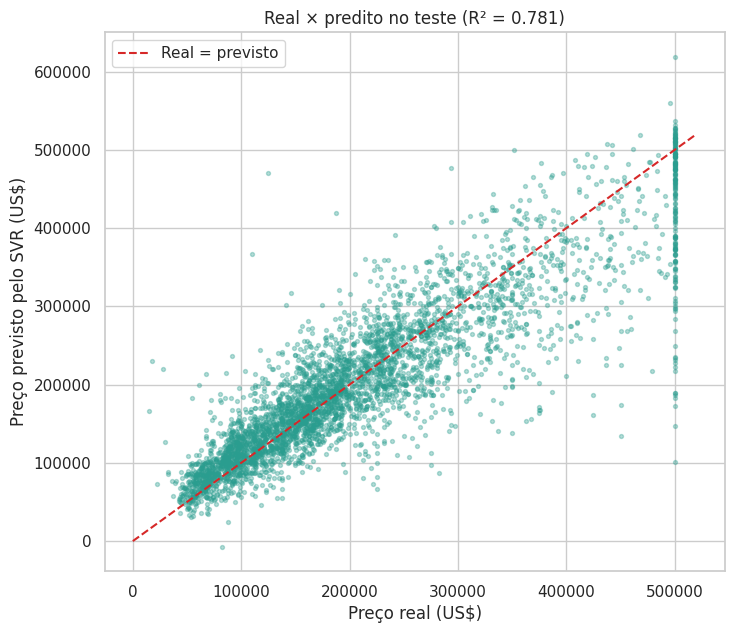

In [27]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred, s=8, alpha=0.35, color="#2a9d8f")
limite = [0, 520000]
plt.plot(limite, limite, color="#d62828", linestyle="--", label="Real = previsto")
plt.xlabel("Preço real (US$)")
plt.ylabel("Preço previsto pelo SVR (US$)")
plt.title(f"Real × predito no teste (R² = {r2:.3f})")
plt.legend()
plt.show()

Cada ponto é um distrito do teste; sobre a linha tracejada a previsão seria exata. A nuvem acompanha a diagonal, principalmente na faixa de preços mais comum (até uns 300 mil dólares).

O que foge do ideal:

- quanto mais caro o distrito, mais espalhados ficam os pontos, isto é, o erro cresce com o preço;
- a coluna de pontos em 500.001 é o grupo com valor truncado. O preço verdadeiro deles não está na base, então o modelo distribui previsões bem diferentes para um mesmo "valor real". É daí que vem a maior parte do erro.

## 14. Tabela de experimentos (Etapa 11 do enunciado)

Registro de tudo o que foi rodado, na sequência, sempre avaliado no mesmo conjunto de teste.

In [28]:
experimentos = pd.DataFrame(historico)
experimentos

,Modelo,Tratamento,Kernel,C,Epsilon,Gamma,R²,MAE,RMSE
0,M1 - Baseline,Sem tratamento,rbf,1,0.1000,scale,-0.0486,"87,340.6137","117,222.0000"
1,M2 - Nulos tratados,Nulos pela mediana + one-hot,rbf,1,0.1000,scale,-0.0487,"87,344.1949","117,229.2477"
2,M3 - Outliers tratados,M2 + corte de outliers (IQR),rbf,1,0.1000,scale,-0.0482,"87,325.0077","117,196.7798"
3,M4 - X padronizado,M3 + StandardScaler em X,rbf,1,0.1000,scale,-0.0424,"86,965.2064","116,874.1773"
4,M5 - X e y padronizados,M4 + StandardScaler em y,rbf,1,0.1000,scale,0.7507,"37,892.5490","57,158.3848"
5,M6 - Novas variáveis,M5 + proporções,rbf,1,0.1000,scale,0.7690,"36,740.0179","55,022.7710"
6,M7 - Final (GridSearch),M6 + GridSearchCV,rbf,10,0.2000,scale,0.7808,"35,931.5002","53,599.5560"


In [29]:
# Versão resumida: modelo, tratamento e R²
experimentos[["Modelo", "Tratamento", "R²"]].round(4)

,Modelo,Tratamento,R²
0,M1 - Baseline,Sem tratamento,-0.0486
1,M2 - Nulos tratados,Nulos pela mediana + one-hot,-0.0487
2,M3 - Outliers tratados,M2 + corte de outliers (IQR),-0.0482
3,M4 - X padronizado,M3 + StandardScaler em X,-0.0424
4,M5 - X e y padronizados,M4 + StandardScaler em y,0.7507
5,M6 - Novas variáveis,M5 + proporções,0.7690
6,M7 - Final (GridSearch),M6 + GridSearchCV,0.7808


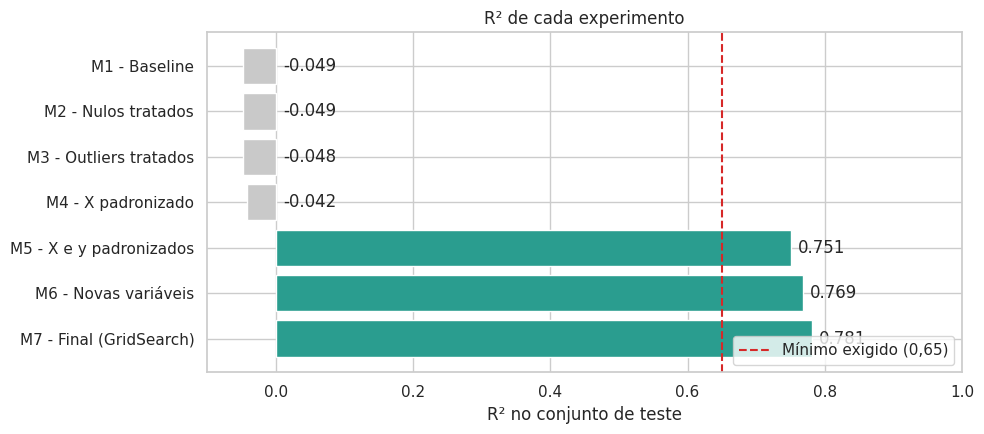

In [30]:
plt.figure(figsize=(10, 4.5))
cores = ["#c9c9c9" if v < 0.65 else "#2a9d8f" for v in experimentos["R²"]]
plt.barh(experimentos["Modelo"], experimentos["R²"], color=cores)
plt.axvline(0.65, color="#d62828", linestyle="--", label="Mínimo exigido (0,65)")
for i, v in enumerate(experimentos["R²"]):
    plt.text(max(v, 0) + 0.01, i, f"{v:.3f}", va="center")
plt.gca().invert_yaxis()
plt.xlim(-0.1, 1.0)
plt.xlabel("R² no conjunto de teste")
plt.title("R² de cada experimento")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 15. Conclusão

**1. O R² passou de 0,65?**  
Passou. No teste, o modelo final chegou a **R² = 0,7808**, com MAE de aproximadamente US$ 35.932 e RMSE de aproximadamente US$ 53.600.

**2. Tratamento de maior impacto**  
A padronização, principalmente a do alvo. Foi a única mudança que tirou o modelo do zero: de −0,0424 para 0,7507.

**3. Tratar outliers ajudou?**  
Ajudou um pouco. Com os dados padronizados, o corte nas contagens levou o R² de 0,7458 para 0,7507. O efeito maior foi indireto: as proporções criadas só renderam depois do corte (0,7458 sem, 0,7690 com). Cortar a renda, ao contrário, atrapalhou.

**4. Melhor kernel**  
RBF (0,7690 com parâmetros padrão), contra 0,7066 do polinomial e 0,6382 do linear.

**5. Hiperparâmetros finais**  
`kernel="rbf"`, `C=10`, `epsilon=0.2`, `gamma="scale"`.

**6. Dificuldades**  
Perceber que o problema inicial era a escala do alvo e não os dados em si; o tempo de treino do SVR com mais de 16 mil linhas, que obrigou a fazer a busca em uma amostra; e os distritos com preço truncado em 500.001, que nenhum ajuste consegue prever bem.

**7. Dá para melhorar?**  
Dá. Possibilidades: refinar a grade em torno de `C=10` usando o treino completo; criar variáveis de localização (distância até grandes centros, agrupamento por coordenadas); dar um tratamento próprio aos distritos truncados; e montar um `Pipeline` para que a mediana e os limites do IQR também sejam aprendidos só no treino.